<a href="https://colab.research.google.com/github/frankelikem/ai-course-lab0-/blob/main/lab0_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

## Exercise 4: NumPy Array Operations

In [2]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [3]:
# Display basic information
print(df.info())

# Count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for student's major
df['exam_score'] = df['exam_score'].fillna(
    df.groupby('major')['exam_score'].transform('mean')
)

# Fill missing hours_studied with median for student's year
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing Values After Cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64


In [4]:
# Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()

print("Average Exam Score by Major:")
print(avg_scores)

# Major with highest average exam score
best_major = avg_scores.idxmax()

print("\nMajor with Highest Average Score:")
print(best_major)

# Correlation
correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation between Hours Studied and Exam Score:")
print(correlation)

# Performance categories
bins = [0, 70, 80, 90, 100]

labels = [
    'Needs Improvement',
    'Average',
    'Good',
    'Excellent'
]

df['performance'] = pd.cut(
    df['exam_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print("\nPerformance Distribution:")
print(df['performance'].value_counts())

Average Exam Score by Major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with Highest Average Score:
CS

Correlation between Hours Studied and Exam Score:
-0.055981383472924404

Performance Distribution:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [5]:
# Summary by major and year

summary = df.groupby(
    ['major', 'year']
).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
})

summary.columns = [
    'num_students',
    'avg_exam_score',
    'avg_hours_studied'
]

print("Major-Year Summary:")
print(summary)

# Top 5 students
top_students = df.nlargest(
    5,
    'exam_score'
)

print("\nTop 5 Students:")
print(top_students)

# Pivot table
pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table:")
print(pivot)

Major-Year Summary:
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13       76.570059          12.677806
        2               12       74.899613          13.426372
        3               14       80.178476          14.486815
        4               15       70.697689          14.253944
CS      1               12       77.098194          13.039480
        2                7       76.155936          13.995784
        3                9       72.347626          15.039892
        4               18       78.119997          16.275541
Math    1               11       74.053167          19.001215
        2                9       81.226714          12.345468
        3               10       72.017537          15.175871
        4               16       73.103066          17.419175
Physics 1               13       77.828686          13.489911
        2               12       73.277734        


### Exercise 5 Summary

Missing values were identified and cleaned using group-based means and medians. Average exam scores were compared across majors, and the relationship between study hours and exam scores was analyzed using correlation. Students were categorized into performance groups, and summary statistics were generated using grouping and pivot tables.

## Exercise 6: Data Visualization

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

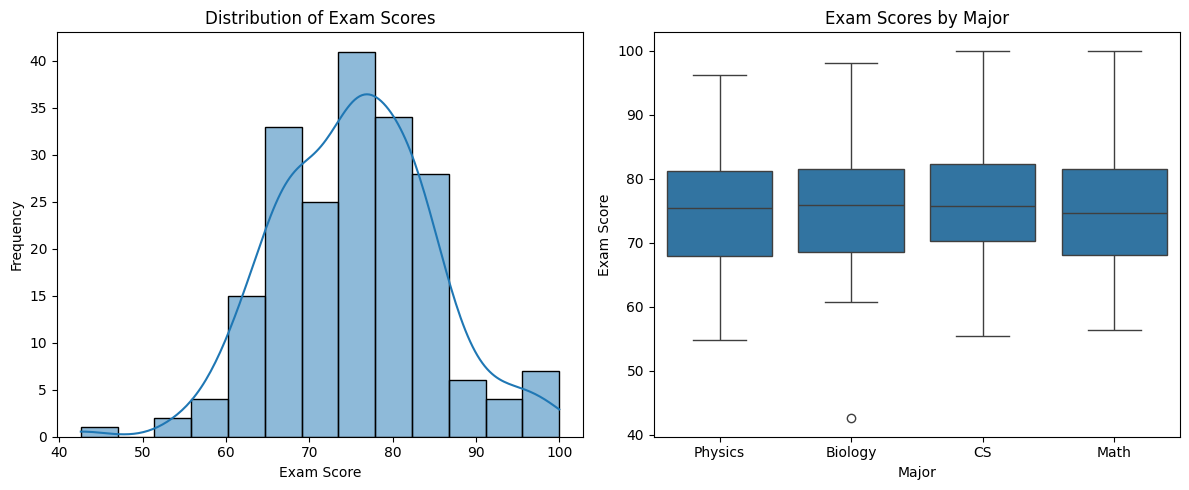

In [7]:
# Create figure with 2 subplots

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE

sns.histplot(
    df['exam_score'],
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')

# Box plot by major

sns.boxplot(
    x='major',
    y='exam_score',
    data=df,
    ax=axes[1]
)

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

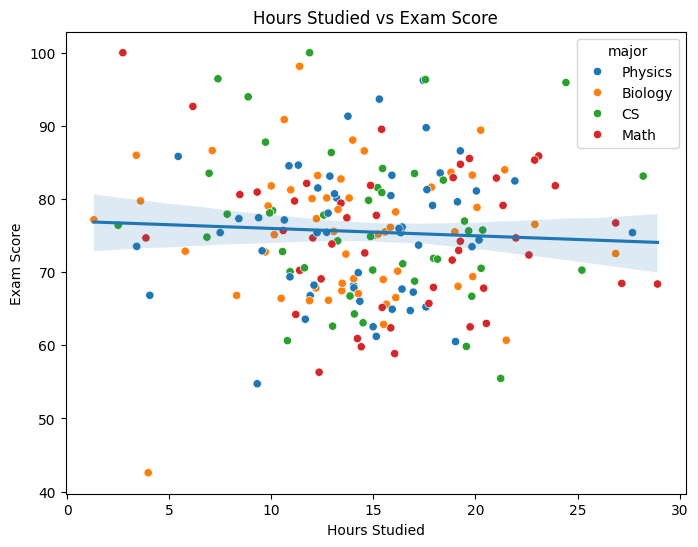

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')

plt.show()

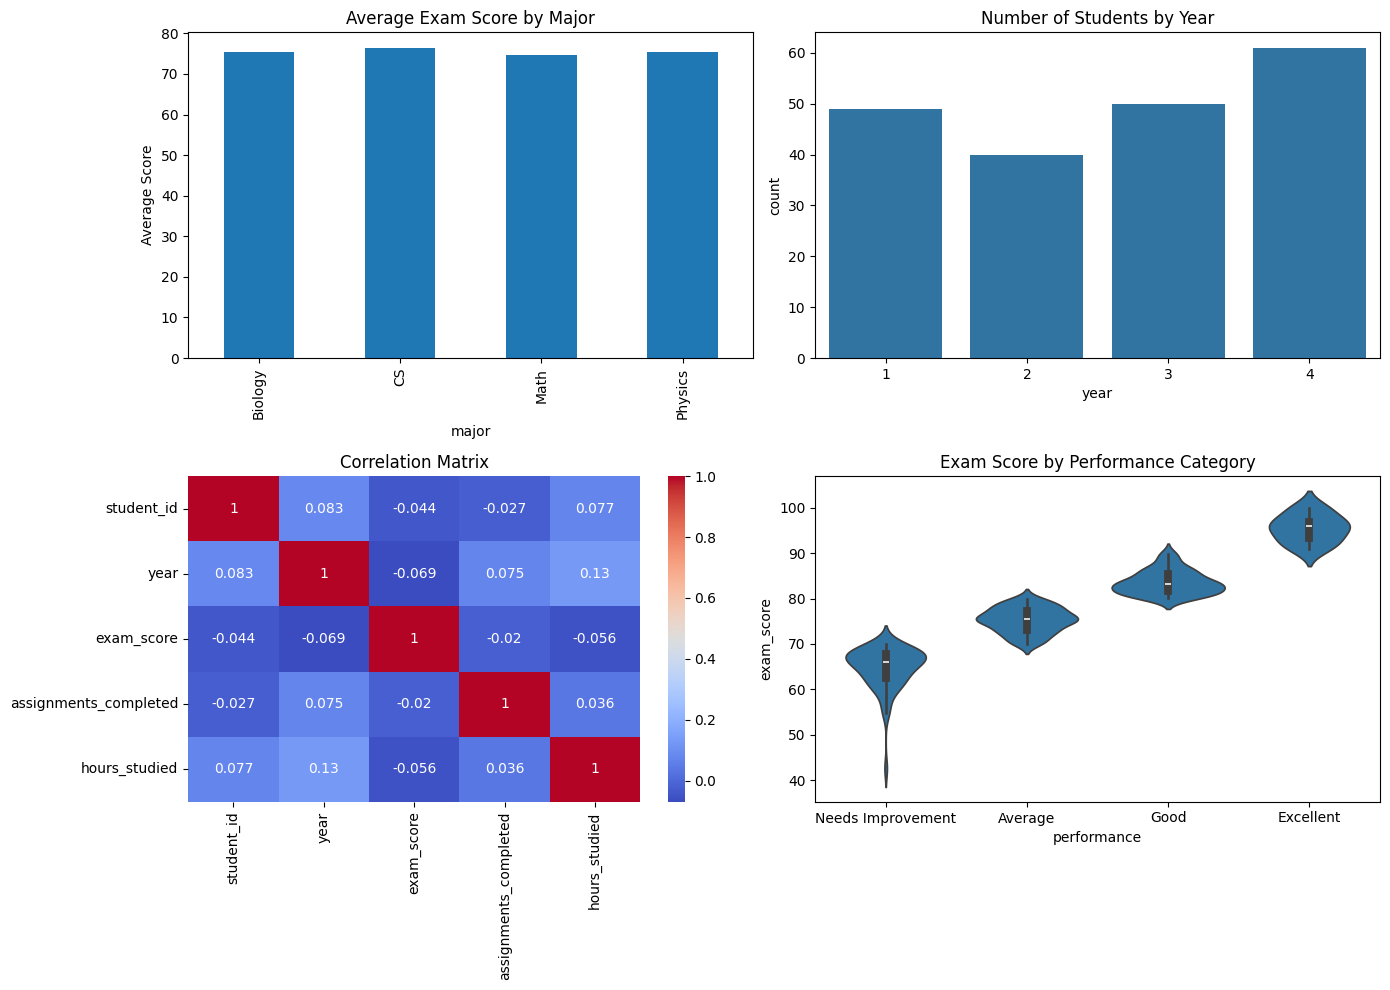

In [9]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# 1. Average exam score by major

avg_scores = df.groupby(
    'major'
)['exam_score'].mean()

avg_scores.plot(
    kind='bar',
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Average Exam Score by Major'
)
axes[0,0].set_ylabel(
    'Average Score'
)

# 2. Number of students by year

sns.countplot(
    data=df,
    x='year',
    ax=axes[0,1]
)

axes[0,1].set_title(
    'Number of Students by Year'
)

# 3. Correlation Heatmap

numeric_df = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Correlation Matrix'
)

# 4. Violin Plot

sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1,1]
)

axes[1,1].set_title(
    'Exam Score by Performance Category'
)

plt.tight_layout()

plt.show()

### Exercise 6 Summary

Several visualizations were created to explore the student performance dataset. Histograms and box plots were used to understand score distributions and compare majors. Scatter plots were used to examine the relationship between study hours and exam scores. A dashboard combining bar charts, count plots, heat maps, and violin plots provided a broader overview of trends and patterns in the dataset.

## Exercise 7: Integration Challenge

In [10]:
np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

In [11]:
# Calculate churn risk

max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

# Calculate CLV

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

print(customers.head())

   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           CLV  
0   937.397271  
1   370.085023  
2   418.424348  
3   477.171887  
4  1097.651683  


In [12]:
bins = [18, 25, 35, 50, 70]

labels = [
    '18-25',
    '26-35',
    '36-50',
    '51-70'
]

customers['age_group'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(customers[['age', 'age_group']].head())

   age age_group
0   56     51-70
1   69     51-70
2   46     36-50
3   32     26-35
4   60     51-70


In [13]:
age_summary = customers.groupby(
    'age_group'
).agg({
    'age': 'count',
    'income': 'mean',
    'CLV': ['mean', 'sum']
})

print(age_summary)

            age        income         CLV               
          count          mean        mean            sum
age_group                                               
18-25        81  50634.018330  718.371170   58188.064760
26-35        73  48747.148046  747.738562   54584.915035
36-50       160  48516.895668  732.796612  117247.457917
51-70       186  50713.163384  762.693498  141860.990683


/tmp/ipykernel_1051/4058801455.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = customers.groupby(


In [14]:
threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= threshold
]

print("Top 10% Customers:")
print(top_customers)

print("\nNumber of Top Customers:")
print(len(top_customers))

Top 10% Customers:
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6     38  58876.388563                  10          110.331527    0.166667   
9     40  48809.492879                  10          110.228581    0.166667   
19    41  21282.756976                   8          119.651218    0.333333   
24    38  53981.193911                   8          120.320786    0.333333   
57    64  45956.146951                   7          135.470585    0.416667   
60    25  66508.326980                   7          142.042870    0.416667   
76    61  62482.396341                   7          127.841352    0.416667   
79    53  32054.912570                  10          108.862819    0.166667   
82    65  69502.394668                  10          117.589989    0.166667   
86    40  58258.629086                   8          127.048701    0.333333   
87    57  38725.508944                   7          150.653265    0.416667   
96    62  35631.115575                   8   

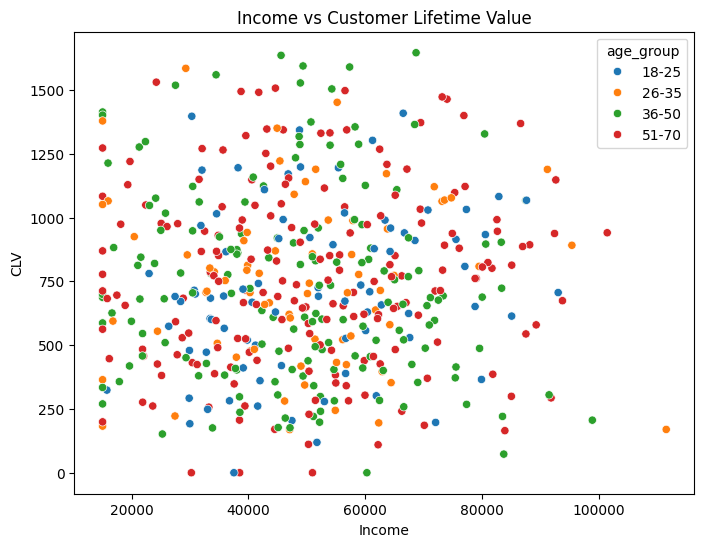

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')

plt.show()

/tmp/ipykernel_1051/3332332095.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby(


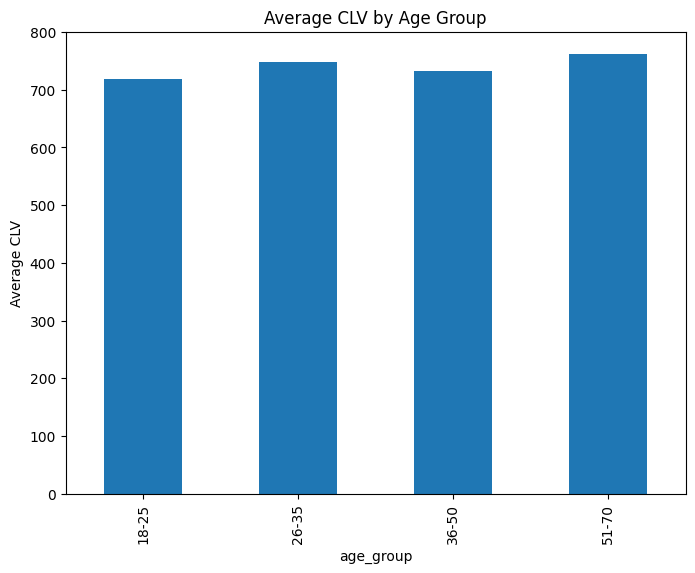

In [16]:
avg_clv = customers.groupby(
    'age_group'
)['CLV'].mean()

plt.figure(figsize=(8,6))

avg_clv.plot(kind='bar')

plt.title('Average CLV by Age Group')
plt.ylabel('Average CLV')

plt.show()

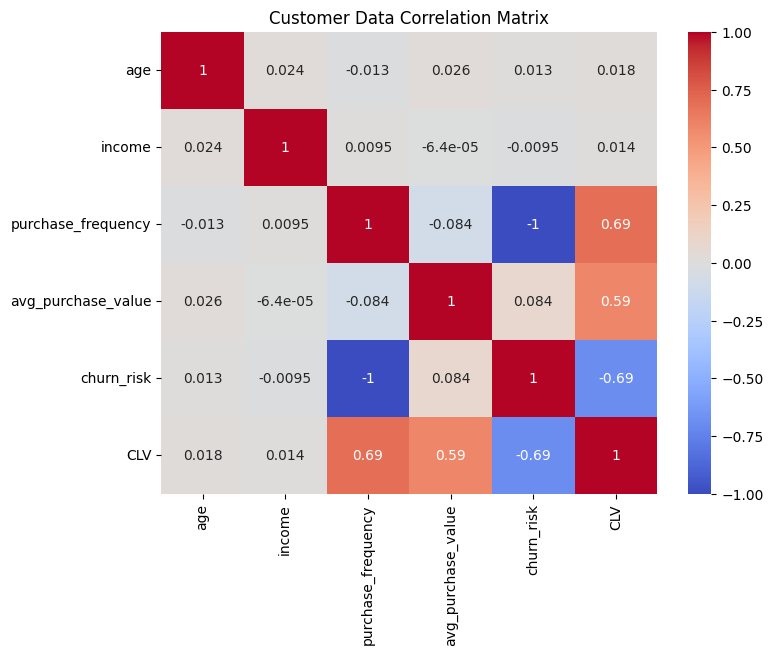

In [17]:
plt.figure(figsize=(8,6))

corr_matrix = customers.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Customer Data Correlation Matrix')

plt.show()

### Exercise 7 Analysis

The customer dataset was analyzed using customer lifetime value (CLV) as a key business metric. Customers were grouped by age, and summary statistics showed differences in income and purchasing behavior across age groups. The top 10% of customers generated significantly higher CLV values and represent an important target segment for marketing and retention efforts. The visualizations indicated relationships between income, purchase behavior, and CLV. Based on these findings, the company should focus on retaining high-CLV customers and developing targeted marketing strategies for age groups with the strongest customer value.